Aggregating the graph at the node and edge level did not work so well, this is because it is dominated by edges in the protein graph. Instead we want to see if given the same seed proteins are orthogonal proteins being predicted across the different modalities

In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
random.seed(42)

What happens when we implement the pLDDT cutoff? nucleic acid and lipid binding sites are most affected.

In [ ]:
for modality in ['protein', 'ion', 'ligand', 'nucleic_acid', 'lipid']:
    dir1 = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/processed/non_disease_disgenet_proteins/"
    dir2 = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/processed/disease_disgenet_proteins/"
    with open(os.path.join(dir1, f"pesto_70_plddt_70_{modality}.pkl"), "rb") as f:
        data1 = pickle.load(f)
    with open(os.path.join(dir2, f"pesto_70_plddt_70_{modality}.pkl"), "rb") as f:
        data2 = pickle.load(f)
    new_data = len(data1)+len(data2)

    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/pesto_processed/pesto_70_plddt_70_{modality}.pkl", "wb") as f:
        pickle.dump(data1+data2, f)

    dir_name = "/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/processed/"
    with open(os.path.join(dir_name, f"non_disease_PeSTo_70_{modality}.pkl"), "rb") as f:
        data1 = pickle.load(f)
    with open(os.path.join(dir_name, f"PeSTo_70_{modality}.pkl"), "rb") as f:
        data2 = pickle.load(f)
    old_data = len(data1)+len(data2)

    print(f"{modality}: {old_data} -> {new_data}")

protein: 19114 -> 17158
ion: 7405 -> 6458
ligand: 6244 -> 5856
nucleic_acid: 10032 -> 6649
lipid: 13356 -> 6766


In [2]:
# cut offs for 90% of the nodes
pesto_cutoff = 70
plddt_cutoff = 70

if pesto_cutoff == 80:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.989,
        "ion": 0.989,
    }
elif pesto_cutoff == 70:
    modality_cutoff = {
        "protein": 0.998,
        "lipid": 0.996,
        "nucleic_acid": 0.996,
        "ligand": 0.993,
        "ion": 0.988,
    }
else:
    raise NotImplementedError("not implemented for this plddt cutoff")

modality_graphs = {}

for modality, cutoff in modality_cutoff.items():
    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_non_disease_PeSTo_80_{modality}.pkl", "rb") as f:
    #     non_disease_embeddings = pickle.load(f)

    # with open(f"/n/netscratch/mzitnik_lab/Lab/afang/InteractNN/protein_universe/function/disgenet/embeddings/prot_interface_version_3_epoch10_step63085/embeddings_PeSTo_80_{modality}.pkl", "rb") as f:
    #     disease_embeddings = pickle.load(f)

    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/embeddings/pesto_{pesto_cutoff}_plddt_{plddt_cutoff}_{modality}.pkl", "rb") as f:
        embeddings_dataset = pickle.load(f)

    embeddings = np.array([x['graph_embedding'] for x in embeddings_dataset])
    uniprot_to_node_idx = {x['id']: i for i, x in enumerate(embeddings_dataset)}

    similarity_matrix = cosine_similarity(embeddings)

    indices = np.triu_indices_from(similarity_matrix, k=1)
    filtered_indices = indices[0][similarity_matrix[indices] > cutoff], indices[1][similarity_matrix[indices] > cutoff]

    print(f"-----------------{modality}-----------------")
    print("Number of embeddings: ", embeddings.shape)
    print("num edges: ", filtered_indices[0].shape[0])

    G = nx.Graph()
    G.add_nodes_from(range(len(embeddings)))
    edges = zip(filtered_indices[0], filtered_indices[1], similarity_matrix[filtered_indices])
    G.add_weighted_edges_from(edges)
    num_connected_components = nx.number_connected_components(G)
    size_of_largest_connected_component = max([len(x) for x in nx.connected_components(G)])
    whole_graph_density = nx.density(G)
    whole_graph_clustering = nx.average_clustering(G)
    print("size of largest connected component: ", size_of_largest_connected_component)
    print("proportion of largest connected component: ", size_of_largest_connected_component / len(embeddings))
    print("number of connected components", num_connected_components)
    print("density: ", whole_graph_density)
    print("clustering: ", whole_graph_clustering)
    print("average degree: ", np.mean([x[1] for x in G.degree()]))

    largest_component = max(nx.connected_components(G), key=len)
    largest_component_subgraph = G.subgraph(largest_component).copy()
    G = largest_component_subgraph

    adjacency_matrix = similarity_matrix > cutoff
    adjacency_matrix = adjacency_matrix.astype(int)
    largest_component_indices = sorted(list(largest_component))
    largest_component_adj_matrix = adjacency_matrix[np.ix_(largest_component_indices, largest_component_indices)]

    modality_graphs[modality] = {
        "graph": G,
        "uniprot_to_node_idx": uniprot_to_node_idx,
        "largest_component": largest_component,
        "filtered_indices": filtered_indices,
        "adjacency_matrix": largest_component_adj_matrix,
    }

-----------------protein-----------------
Number of embeddings:  (17158, 32)
num edges:  261673
size of largest connected component:  15421
proportion of largest connected component:  0.8987644247581303
number of connected components 1394
density:  0.0017777917823615932
clustering:  0.41121885853388995
average degree:  30.501573609977854
-----------------lipid-----------------
Number of embeddings:  (6766, 32)
num edges:  157164
size of largest connected component:  6072
proportion of largest connected component:  0.8974283180608927
number of connected components 541
density:  0.006867256590766537
clustering:  0.44944977239782463
average degree:  46.45699083653562
-----------------nucleic_acid-----------------
Number of embeddings:  (6649, 32)
num edges:  114405
size of largest connected component:  6031
proportion of largest connected component:  0.907053692284554
number of connected components 500
density:  0.005176397960009187
clustering:  0.4494694800899958
average degree:  34.4126

## Disease Associations

It seems that the quality of nucleic acid predictions by Pesto is quite poor, we could strengthen the prediction by using GO term filtering as well?

In [3]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv",
                                sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names', 'Gene Ontology (molecular function)'])

In [4]:
uniprot_human_df.dropna(subset=['Gene Ontology (molecular function)'], inplace=True)
# GO nucleic acid binding
uniprot_human_df = uniprot_human_df[uniprot_human_df['Gene Ontology (molecular function)'].str.contains("GO:0003676")]
uniprot_to_node_idx = modality_graphs['nucleic_acid']['uniprot_to_node_idx']
node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
largest_component = modality_graphs['nucleic_acid']['largest_component']
uniprots_nucleic = [node_idx_to_uniprot[x] for x in largest_component]
uniprot_human_df['Entry'].isin(uniprots_nucleic).sum(), len(uniprots_nucleic), len(uniprot_human_df)

(63, 6031, 998)

Load all disease associated csvs

In [5]:
uniprot_human_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/uniprot/uniprotkb_AND_model_organism_9606_2024_12_16.tsv", sep="\t", usecols=['Entry', 'Entry Name', 'Protein names', 'Gene Names'])
uniprot_to_gene = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Gene Names']))
uniprot_to_protein_name = dict(zip(uniprot_human_df['Entry'], uniprot_human_df['Protein names']))

In [6]:
# with open("/n/holylfs06/LABS/mzitnik_lab/Lab/PLM/integrated_data/v1/disgenet/disgenet_info_filtered.pkl", "rb") as f:
#     disgenet_info = pickle.load(f)

# relations_df = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/PLM/integrated_data/v1/protein_disgenet/area_protein_aware_disgenet_centric/protein_disgenet_relations.unified.csv")
# disease_counts = relations_df.text_id.value_counts()
# top_diseases = disease_counts[disease_counts > 25].index.tolist()
# print(len(top_diseases))

# replace with open targets diseases
# disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/diamond_association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
# disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
# disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
# disease_associations

In [7]:
chosen_diseases = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/chosen_diseases.csv')
disease_associations = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5.csv')
disease_associations = disease_associations[disease_associations['diseaseId'].isin(chosen_diseases['diseaseId'])]
disease_id_to_name = dict(zip(disease_associations['diseaseId'], disease_associations['diseaseName']))
disease_name_to_id = dict(zip(disease_associations['diseaseName'], disease_associations['diseaseId']))
print("Number of unique diseases: ", len(disease_associations['diseaseId'].unique()))
disease_associations

Number of unique diseases:  105


,diseaseId,targetId,score,evidenceCount,uniprot_targetId,diseaseName
2754,MONDO_0015760,ENSG00000026103,0.511482,31,P25445,T-cell non-Hodgkin lymphoma
2755,MONDO_0015760,ENSG00000048052,0.520368,257,Q9UKV0,T-cell non-Hodgkin lymphoma
2756,MONDO_0015760,ENSG00000055609,0.507134,13,Q8NEZ4,T-cell non-Hodgkin lymphoma
2757,MONDO_0015760,ENSG00000061273,0.505264,14,Q8WUI4,T-cell non-Hodgkin lymphoma
2758,MONDO_0015760,ENSG00000068024,0.505264,14,P56524,T-cell non-Hodgkin lymphoma
...,...,...,...,...,...,...
182470,EFO_1002049,ENSG00000239732,0.544995,126,Q9NR96,glomerular disease
182471,EFO_1002049,ENSG00000244414,0.587819,67,Q03591,glomerular disease
182869,EFO_1002049,ENSG00000138760,0.695206,118,Q14108,glomerular disease
182870,EFO_1002049,ENSG00000148204,0.821178,73,Q5IJ48,glomerular disease


In [8]:
modality_disease_counts = pd.read_csv(f"/n/holylabs/LABS/mzitnik_lab/Users/afang/GET/case_studies/network_analysis/modality_chosen_disease_counts_pesto_{pesto_cutoff}_plddt_{plddt_cutoff}.csv")
modality_disease_counts = pd.pivot_table(modality_disease_counts, 
                            values="num_proteins", 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
# modality_disease_counts = modality_disease_counts.reset_index()
# modality_disease_counts = modality_disease_counts.sort_values(by="diseaseName")
# module_cutoff = 25
# modality_disease_counts_filtered = modality_disease_counts[(modality_disease_counts.ion > module_cutoff) & (modality_disease_counts.ligand > module_cutoff) & (modality_disease_counts.lipid > module_cutoff) & (modality_disease_counts.nucleic_acid > module_cutoff) & (modality_disease_counts.protein > module_cutoff)]
# print(f"Passed module_cutoff n={module_cutoff}: {len(modality_disease_counts_filtered)} out of {len(modality_disease_counts)}")
# modality_disease_counts_filtered.to_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5_modality_disease_counts.csv", index=False)

# modality_disease_counts_filtered = pd.read_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_overall_indirect_disease_counts_cutoff_0.5_modality_disease_counts.csv")
# modality_disease_counts_filtered = modality_disease_counts_filtered[modality_disease_counts_filtered.keep == 1]
# print("Number of diseases: ", len(modality_disease_counts_filtered))
# disease_associations = disease_associations[disease_associations.diseaseId.isin(modality_disease_counts_filtered.diseaseId)]
# disease_associations.to_csv("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/filtered_by_module_size_25_association_by_overall_indirect_disease_counts_cutoff_0.5.csv")

In [9]:
modalities = ['ion', 'ligand', 'lipid', 'nucleic_acid', 'protein']
modality_disease_counts['is_valid'] = modality_disease_counts.apply(lambda row: sum([1 for x in modalities if row[x] >= 25]) >= 2, axis=1)
modality_disease_counts[modality_disease_counts['is_valid']].head(50)

,modality,ion,ligand,lipid,nucleic_acid,protein,is_valid
diseaseId,diseaseName,,,,,,
EFO_0000181,head and neck squamous cell carcinoma,17.0,31.0,9.0,22.0,31.0,True
EFO_0000195,metabolic syndrome,11.0,8.0,30.0,8.0,53.0,True
EFO_0000304,breast adenocarcinoma,36.0,35.0,18.0,53.0,75.0,True
EFO_0000318,cardiomyopathy,76.0,79.0,79.0,51.0,149.0,True
EFO_0000365,colorectal adenocarcinoma,46.0,46.0,22.0,70.0,101.0,True
EFO_0000400,diabetes mellitus,72.0,49.0,101.0,54.0,155.0,True
EFO_0000474,epilepsy,106.0,100.0,137.0,64.0,219.0,True
EFO_0000538,hypertrophic cardiomyopathy,42.0,44.0,25.0,30.0,80.0,True
EFO_0000574,lymphoma,111.0,107.0,72.0,124.0,203.0,True


In [10]:
# cross_validation_assignments = {}
# for seed in range(100):
#     np.random.seed(seed)
#     for disease in chosen_diseases['diseaseId'].unique():
#         disease_proteins = disease_associations[disease_associations['diseaseId'] == disease]['uniprot_targetId'].unique()
#         disease_proteins = np.random.permutation(disease_proteins)
#         num_folds = 5
#         folds = np.array_split(disease_proteins, num_folds)
#         for i in range(num_folds):
#             train_proteins = np.concatenate([folds[j] for j in range(num_folds) if j != i])
#             test_proteins = folds[i]

#             cross_validation_assignments[(disease, i)] = {
#                 "train_proteins": train_proteins,
#                 "test_proteins": test_proteins,
#             }
#     with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/cv_splits/cv_split_{seed}.pkl", "wb") as f:
#         pickle.dump(cross_validation_assignments, f)

## Visualising networks

In [10]:
chosen_modality = 'ion'
G = modality_graphs[chosen_modality]['graph'].copy()
uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
largest_component = modality_graphs[chosen_modality]['largest_component']

node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
uniprots_in_graph = [x for x in uniprot_to_node_idx if uniprot_to_node_idx[x] in largest_component]
uniprots_to_disease = {}
for uniprot in uniprots_in_graph:
    diseases = disease_associations[disease_associations['uniprot_targetId'] == uniprot]
    if len(diseases) > 1:
        uniprots_to_disease[uniprot] = "multiple"
    elif len(diseases) == 1:
        uniprots_to_disease[uniprot] = disease_id_to_name[diseases['diseaseId'].unique()[0]]
    else:
        uniprots_to_disease[uniprot] = "none"

# nodes_to_remove = [node for node in G.nodes if uniprots_to_disease.get(node_idx_to_uniprot[node], 'none') == 'none']
# G.remove_nodes_from(nodes_to_remove)

# Create a mapping from node types to colors
from matplotlib import cm
from matplotlib.colors import Normalize, to_rgb
cmap = sns.color_palette("Spectral", as_cmap=True)

unique_diseases = set(uniprots_to_disease.values())
norm = Normalize(vmin=0, vmax=len(unique_diseases) - 1)
type_color_map = {
    type_name: to_rgb(cmap(norm(i))) for i, type_name in enumerate(unique_diseases)
}
type_color_map['none'] =  (0.75,0.75,0.75)
type_color_map['multiple'] = (0.5,0.5,0.5)

node_colors = [type_color_map[uniprots_to_disease[node_idx_to_uniprot[node]]] for node in G.nodes]

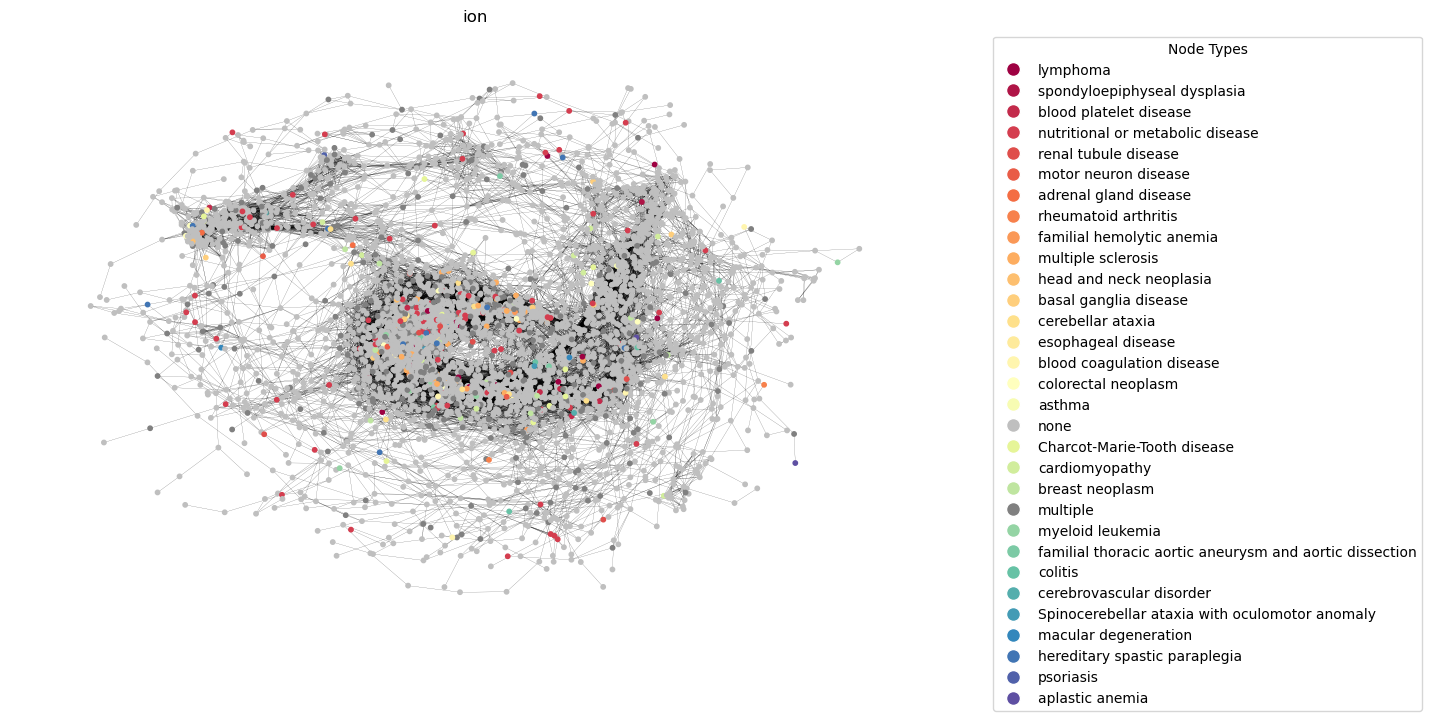

In [6]:
# Draw the network graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=3/np.sqrt(G.order()))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=10)
nx.draw_networkx_edges(G, pos, width=0.1)

# Add a legend to show color correspondence
handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=type_name)
    for type_name, color in type_color_map.items()
]
plt.legend(handles=handles, title="Node Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title(chosen_modality)
plt.axis('off')
plt.show()

visualise in Gephi or CytoScape

In [8]:
chosen_modality = 'lipid'
chosen_disease = 'asthma'
G = modality_graphs[chosen_modality]['graph'].copy()
uniprot_to_node_idx = modality_graphs[chosen_modality]['uniprot_to_node_idx']
largest_component = modality_graphs[chosen_modality]['largest_component']
adjacency_matrix = modality_graphs[chosen_modality]['adjacency_matrix']

node_information = []

node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
for node in largest_component:
    uniprot = node_idx_to_uniprot[node]
    diseases = disease_associations[disease_associations['uniprot_targetId'] == uniprot]['diseaseName'].unique()
    is_chosen_disease = chosen_disease in diseases

    if len(diseases) > 1:
        disease = 'multiple'
    elif len(diseases) == 1:
        disease = diseases[0]
    else:
        disease = 'none'
    
    gene = uniprot_to_gene.get(uniprot, uniprot)
    if pd.isna(gene):
        gene = uniprot

    G.nodes[node]['disease'] = disease
    G.nodes[node]['protein'] = uniprot
    G.nodes[node]['gene'] = gene
    G.nodes[node][chosen_disease] = is_chosen_disease
    node_information.append(
        {
            'Id': node,
            'Disease': disease,
            'Label': uniprot,
            'Gene': gene,
        }
    )

node_information = pd.DataFrame(node_information)

# edge_list = []
# for source, target in G.edges():
#     edge_list.append((source, target))
# edge_information = pd.DataFrame(edge_list, columns=['Source', 'Target'])

# node_information.to_csv(f'visualisation/{chosen_modality}_nodes.csv', index=False)
# edge_information.to_csv(f'visualisation/{chosen_modality}_edges.csv', index=False)
nx.write_gexf(G, f'visualisation/{chosen_modality}_{chosen_disease}.gexf')

In [59]:
len(node_information['Gene'].unique()), len(node_information)

(5648, 5651)

to do: double check the missing ones, either missing because of AF2 file is missing, or because PESTO does not predict an interface.

## How are disease proteins distributed across the different modalities

In [5]:
for modality in modality_graphs:
    largest_component = modality_graphs[modality]['largest_component']
    largest_component_uniprots = [k for k,v in modality_graphs[modality]['uniprot_to_node_idx'].items() if v in largest_component]
    disease_associations[modality] = disease_associations['uniprot_targetId'].isin(largest_component_uniprots)
disease_associations['aggregated'] = sum([disease_associations[x] for x in modality_graphs.keys()])
disease_associations['aggregated'].value_counts()

aggregated
2    2321
1    1903
3    1088
0     411
4     304
5      19
Name: count, dtype: int64

In [6]:
all_diseases = disease_associations.groupby('diseaseId').agg({'uniprot_targetId': list}).reset_index()
multimodality_diseases = disease_associations[disease_associations['aggregated'] == 5].groupby('diseaseId').agg({'uniprot_targetId': list}).reset_index()
multimodality_diseases = multimodality_diseases[multimodality_diseases['uniprot_targetId'].apply(len) >= 5]
multimodality_diseases = multimodality_diseases.merge(all_diseases, on='diseaseId', suffixes=('_seed', '_all'))
len(multimodality_diseases)

1

In [ ]:
# cross_validation_assignments = {}
# for row in multimodality_diseases.itertuples():
#     disease = row.text_id
#     train_proteins = row.seq_id_seed
#     test_proteins = list(set(row.seq_id_all) - set(row.seq_id_seed))
#     cross_validation_assignments[(disease, 0)] = {
#         "train_proteins": train_proteins,
#         "test_proteins": test_proteins,
#     }
#     print(disease, len(train_proteins)/(len(train_proteins) + len(test_proteins)))
# with open("cv_split_all_modality.pkl", "wb") as f:
#     pickle.dump(cross_validation_assignments, f)

C0006142 0.008919722497522299
C0009402 0.018292682926829267
C0023893 0.00796812749003984
C0036341 0.008438818565400843
C0678222 0.01
C1257931 0.010245901639344262
C4704874 0.010245901639344262


## How connected is a disease to itself?

In [11]:
def get_disease_connectivity(modality, disease_id):
    G = modality_graphs[modality]['graph'].copy()
    uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
    node_idx_to_uniprot = {v: k for k, v in uniprot_to_node_idx.items()}
    largest_component = modality_graphs[modality]['largest_component']

    filtered_relations_df = disease_associations[disease_associations['diseaseId'] == disease_id].copy()
    number_of_disease_proteins = len(filtered_relations_df['uniprot_targetId'].unique())
    filtered_relations_df['node_idx'] = filtered_relations_df['uniprot_targetId'].map(uniprot_to_node_idx).fillna(-1).astype(int)
    filtered_relations_df = filtered_relations_df[(filtered_relations_df['node_idx'] != -1) & (filtered_relations_df['node_idx'].isin(largest_component))].copy()
    selected_disease_nodes = filtered_relations_df['node_idx'].tolist()

    if len(selected_disease_nodes) == 0:
        return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": 0, 
                "number_of_nodes": 0, "size_of_largest_pathway_component": 0, "num_components": 0, 
                "density": 0, "clustering": 0, "proteins_in_largest_component": []}

    subgraph = G.subgraph(selected_disease_nodes)
    largest_component = max(nx.connected_components(subgraph), key=len)
    size_of_largest_component = len(largest_component)
    subgraph_num_components = nx.number_connected_components(subgraph)
    subgraph_density = nx.density(subgraph)
    subgraph_clustering = nx.average_clustering(subgraph)
    number_of_nodes = len(selected_disease_nodes)
    proteins = [node_idx_to_uniprot[x] for x in largest_component]
    all_proteins = [node_idx_to_uniprot[x] for x in selected_disease_nodes]
    
    return {"modality": modality, "diseaseId": disease_id, "size_of_largest_connected_component": size_of_largest_component, 
            "number_of_nodes": number_of_nodes, "relative_size_of_largest_pathway_component": size_of_largest_component/number_of_nodes, 
            "relative_size_of_number_of_nodes": number_of_nodes/number_of_disease_proteins,
            "num_components": subgraph_num_components, "density": subgraph_density, "clustering": subgraph_clustering,
            "proteins_in_largest_component": proteins, 'all_proteins': all_proteins}


disease_connectivity = []
for disease_id in tqdm(disease_associations['diseaseId'].unique(), total=len(disease_associations['diseaseId'].unique())):
    for modality in modality_graphs:
        disease_connectivity.append(get_disease_connectivity(modality, disease_id))

disease_connectivity_df = pd.DataFrame(disease_connectivity)
disease_connectivity_df['diseaseName'] = disease_connectivity_df['diseaseId'].map(disease_id_to_name)
disease_connectivity_df.sort_values('num_components', ascending=True)

100%|██████████| 105/105 [05:36<00:00,  3.20s/it]


,modality,diseaseId,size_of_largest_connected_component,number_of_nodes,relative_size_of_largest_pathway_component,relative_size_of_number_of_nodes,num_components,density,clustering,proteins_in_largest_component,all_proteins,diseaseName
338,ligand,MONDO_0000774,1,3,0.333333,0.068182,3,0.000000,0.000000,[O95259],"[P22303, P01031, O95259]",autoimmune neuropathy
141,lipid,EFO_0000673,1,3,0.333333,0.088235,3,0.000000,0.000000,[P30968],"[P30968, P10275, O15393]",prostate adenocarcinoma
109,ion,Orphanet_309005,1,3,0.333333,0.111111,3,0.000000,0.000000,[Q8NBP7],"[Q9H490, Q8NBP7, Q07869]",Disorder of lipid metabolism
259,ion,EFO_0005251,3,5,0.600000,0.142857,3,0.200000,0.000000,"[P07550, P31644, O14649]","[P57789, O14649, P31644, Q7Z418, P07550]",hypotension
192,nucleic_acid,MONDO_0009723,1,4,0.250000,0.102564,4,0.000000,0.000000,[P54098],"[Q9BSH4, P42704, P03891, P54098]",Leigh syndrome
...,...,...,...,...,...,...,...,...,...,...,...,...
10,protein,EFO_0000474,8,219,0.036530,0.820225,171,0.002430,0.058904,"[P04040, Q96MT3, P17600, Q7L3T8, P16389, P0050...","[Q96QS3, Q9BRB3, P17600, O76039, Q9BYZ6, P3490...",epilepsy
55,protein,EFO_0000574,15,203,0.073892,0.685811,176,0.001707,0.032512,"[Q8NFD5, P48735, P54278, O75533, P12268, Q1546...","[Q92793, P40259, P20273, Q14181, P42768, P2544...",lymphoma
171,lipid,OTAR_0000020,284,630,0.450794,0.415020,182,0.014399,0.360646,"[Q9Y5Y5, Q6DD88, Q9NQ11, P14672, P31645, Q1472...","[O60762, Q9UJS0, P30988, P21439, P13473, Q0942...",nutritional or metabolic disease
390,protein,EFO_0003869,30,348,0.086207,0.822695,232,0.002567,0.111287,"[P57789, Q9Y6X0, Q8WYB5, Q8TCU5, O95169, O7530...","[O14561, Q92793, P40259, P34903, P38398, Q1418...",breast neoplasm


Number of diseases with sufficient data: 68 out of 103


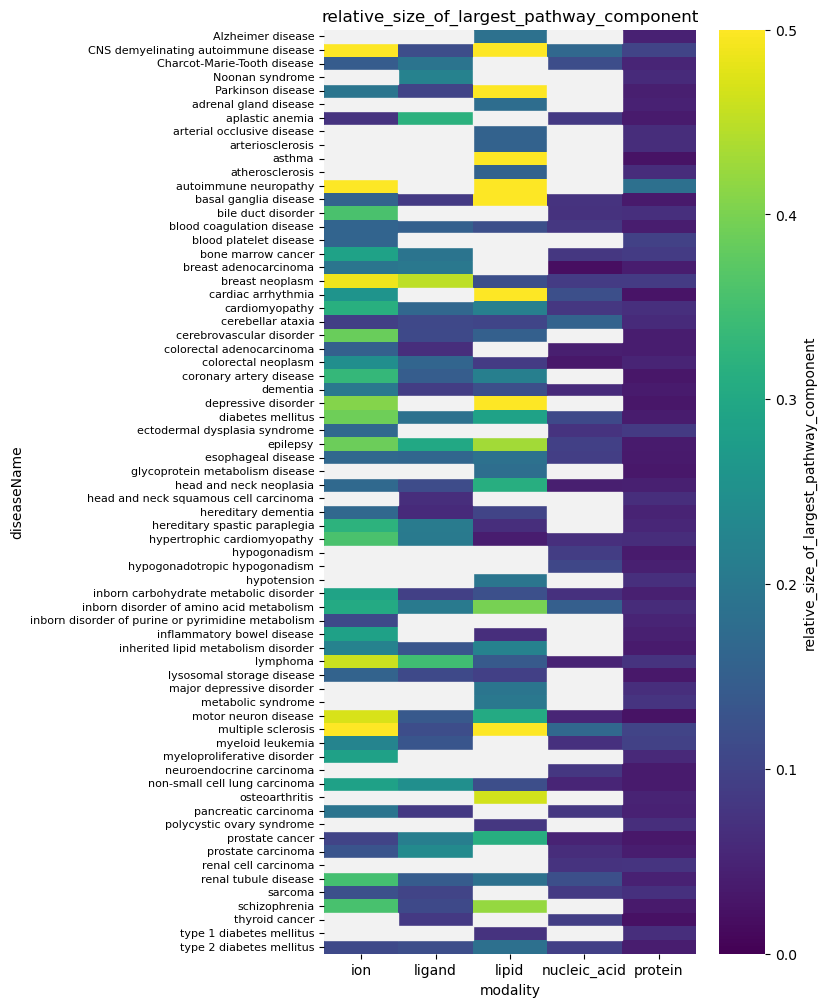

In [12]:
chosen_metric = 'relative_size_of_largest_pathway_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df = pivoted_df[~pivoted_df['diseaseName'].isin(['nutritional or metabolic disease', 'thyroid carcinoma'])]

# remove the diseases with less than 25 proteins
min_modality_protein_count = 25
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    pivoted_df[modality] = pivoted_df.apply(lambda row: row[modality] if modality_disease_counts.loc[(row['diseaseId'], row['diseaseName'])][modality] >= min_modality_protein_count else -1, axis=1)

pivoted_df['sufficient_data'] = pivoted_df.apply(lambda row: sum([1 for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid'] if row[modality] != -1]) > 1, axis=1)
print(f"Number of diseases with sufficient data: {sum(pivoted_df['sufficient_data'])} out of {len(pivoted_df)}")
pivoted_df = pivoted_df[pivoted_df['sufficient_data']]
pivoted_df = pivoted_df.drop('sufficient_data', axis=1)

plt.figure(figsize=(6,12))
plotting_df = pivoted_df.set_index('diseaseName').drop('diseaseId', axis=1)
mask = plotting_df==-1
ax = sns.heatmap(plotting_df, cmap='viridis', mask=mask, cbar_kws={"label": chosen_metric}, vmin=0, vmax=0.5) #max([plotting_df[col].max() for col in plotting_df.columns]))
for i, j in zip(*np.where(mask)):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fc='#F2F2F2', ec='#F2F2F2'))
ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.yticks(np.arange(len(plotting_df)) + 0.5, plotting_df.index, rotation=0)
plt.yticks(fontsize=8)
plt.title(chosen_metric)
plt.show()

In [17]:
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    print(f"{modality}: {round(pivoted_df[pivoted_df[modality] > 0][modality].mean(), 3)}, {round(pivoted_df[pivoted_df[modality] > 0][modality].std(), 3)}")

protein: 0.054, 0.025
ligand: 0.161, 0.082
nucleic_acid: 0.084, 0.035
ion: 0.278, 0.159
lipid: 0.252, 0.174


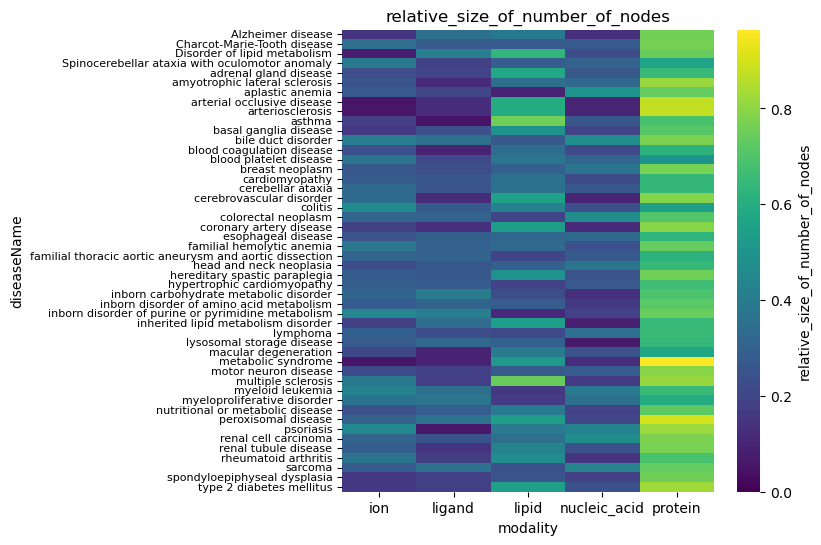

In [11]:
chosen_metric = 'relative_size_of_number_of_nodes'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')

plt.figure(figsize=(6,6))
plotting_df = pivoted_df.set_index('diseaseName').drop('diseaseId', axis=1)
ax = sns.heatmap(plotting_df, cmap='viridis', cbar_kws={"label": chosen_metric}, vmin=0, vmax=max([plotting_df[col].max() for col in plotting_df.columns]))

ax.set_yticklabels(ax.get_yticklabels(), va='center')
plt.yticks(np.arange(len(plotting_df)) + 0.5, plotting_df.index, rotation=0)
plt.yticks(fontsize=8)
plt.title(chosen_metric)
plt.show()

comparing level of evidence for different modalities for a given disease with a swarm plot

this does not seem to work so well. I don't think there is a higher level of evidence for a given disease in a given modality.

       uniprot_targetId     score      modality
165265           P14416  0.630924         lipid
165237           Q04637  0.624952  nucleic_acid
165222           P21917  0.608907         lipid
165238           O60391  0.604589         lipid
165255           Q99250  0.590957         lipid
165297           P21728  0.587740         lipid
165246           P29274  0.573232         lipid
165252           P20309  0.567148         lipid
165218           P08588  0.564885         lipid
165301           P13945  0.563054         lipid
165267           P08913  0.554763         lipid
165285           O43920  0.544390       protein
165263           P28335  0.544006         lipid
165381           Q9NY46  0.534457         lipid
165303           Q9UQD0  0.533101         lipid
165279           P53350  0.526785        ligand
165261           P35498  0.526651         lipid
165254           P11802  0.526138        ligand
165248           P49918  0.523811       protein
165287           P06493  0.513878       

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


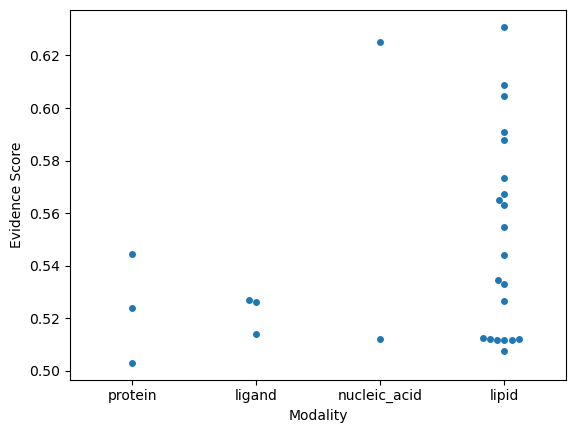

In [48]:
chosen_disease = 'Parkinson disease'
chosen_disease_id = disease_name_to_id[chosen_disease]
min_modality_protein_count = 25

evidence_scores_to_plot = []
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    largest_component_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == modality)]['proteins_in_largest_component'].values[0]
    if len(largest_component_proteins) == 0 or modality_disease_counts.loc[(chosen_disease_id, chosen_disease)][modality] < min_modality_protein_count:
        continue
    evidence_scores = disease_associations[(disease_associations['diseaseId'] == chosen_disease_id) & (disease_associations['uniprot_targetId'].isin(largest_component_proteins))][['uniprot_targetId', 'score']].copy()
    evidence_scores['modality'] = modality
    evidence_scores_to_plot.append(evidence_scores)

evidence_scores_to_plot = pd.concat(evidence_scores_to_plot)
print(evidence_scores_to_plot.sort_values('score', ascending=False))

sns.swarmplot(x='modality', y='score', data=evidence_scores_to_plot)
plt.xlabel('Modality')
plt.ylabel('Evidence Score')
plt.show()

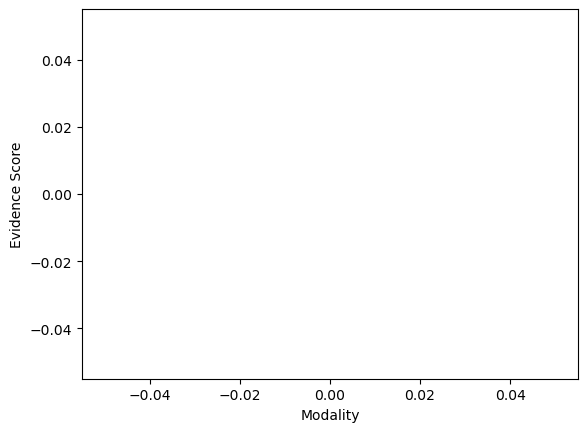

In [12]:
chosen_disease = 'asthma'
chosen_datatype = 'literature'
chosen_disease_id = disease_name_to_id[chosen_disease]
min_modality_protein_count = 25

disease_association_evidence_scores = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/association_by_datatype_indirect_disease_counts_cutoff_0.5.csv')
disease_association_evidence_scores = disease_association_evidence_scores[(disease_association_evidence_scores['diseaseId'] == chosen_disease_id) & (disease_association_evidence_scores['datatypeId'] == chosen_datatype)]

evidence_scores_to_plot = []
for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
    largest_component_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == modality)]['proteins_in_largest_component'].values[0]
    if len(largest_component_proteins) == 0 or modality_disease_counts.loc[(chosen_disease_id, chosen_disease)][modality] < min_modality_protein_count:
        continue
    evidence_scores = disease_association_evidence_scores[(disease_association_evidence_scores['uniprot_targetId'].isin(largest_component_proteins))][['uniprot_targetId', 'score']].copy()
    evidence_scores['modality'] = modality
    evidence_scores_to_plot.append(evidence_scores)

evidence_scores_to_plot = pd.concat(evidence_scores_to_plot)

sns.swarmplot(x='modality', y='score', data=evidence_scores_to_plot)
plt.xlabel('Modality')
plt.ylabel('Evidence Score')
plt.show()

In [79]:
chosen_disease = 'nutritional or metabolic disease'
chosen_modality = 'nucleic_acid'
largest_component_disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['proteins_in_largest_component'].values[0]
disease_proteins = disease_connectivity_df[(disease_connectivity_df['diseaseName'] == chosen_disease) & (disease_connectivity_df['modality'] == chosen_modality)]['all_proteins'].values[0]
print("number of disease proteins in largest component", len(largest_component_disease_proteins))
print("disease proteins in largest component", " ".join(largest_component_disease_proteins))
print("number of disease proteins", len(disease_proteins))
print("disease proteins", " ".join(disease_proteins))

number of disease proteins in largest component 51
disease proteins in largest component P40939 Q07866 P55017 P05067 Q8WZA1 Q8N511 Q9NYK1 Q92878 P50607 Q9UQ90 P30566 Q96F86 P78363 Q9Y6M9 P29120 O43451 Q92786 Q8N157 Q53H12 O95461 P13807 Q15031 Q7Z4Q2 Q8NBU5 Q8TCS8 Q3B820 P08913 Q13615 Q9NS56 Q01118 P02788 P35499 Q96MW5 P42261 P14867 Q96EN8 Q5K651 Q96L58 P07954 Q96AQ7 Q49MI3 P19447 Q05469 P32004 O15287 Q86XK2 Q9BT22 P46019 Q969N2 Q9NVI1 Q9BW92
number of disease proteins 286
disease proteins Q6SZW1 P21439 Q09428 Q53H12 Q9BQ52 P35228 P35499 P26367 Q92481 P31629 Q15031 P02788 Q96RI1 P14867 Q92887 Q9BT22 Q08J23 Q9NUW8 Q9H3H1 P46019 Q9P2K1 Q14766 Q9BVS4 O75879 O14617 O95625 P55017 Q9Y6M1 P82930 Q96EN8 P43003 Q05469 O43520 P06401 P40939 Q8WZA1 Q5JWF2 P49588 O43511 P07954 P03372 O43175 P49366 P17568 O00411 Q13615 Q6PJT7 O15091 P41235 Q13469 O94906 P33897 O60840 P15976 O95822 Q5XUX0 Q5JPH6 P09668 Q9P2K5 O60934 P13807 Q9NP81 P18074 Q9NXH9 Q9Y463 P39019 O43186 Q8WWY3 O43316 P10071 P01031 Q8NEA6 Q7

In [80]:
for protein in largest_component_disease_proteins:
    print(protein, "|", uniprot_to_gene.get(protein, protein), "|", uniprot_to_protein_name.get(protein, protein))

P40939 | HADHA HADH | Trifunctional enzyme subunit alpha, mitochondrial (78 kDa gastrin-binding protein) (Monolysocardiolipin acyltransferase) (EC 2.3.1.-) (TP-alpha) [Includes: Long-chain enoyl-CoA hydratase (EC 4.2.1.17); Long chain 3-hydroxyacyl-CoA dehydrogenase (EC 1.1.1.211)]
Q07866 | KLC1 KLC KNS2 | Kinesin light chain 1 (KLC 1)
P55017 | SLC12A3 NCC TSC | Solute carrier family 12 member 3 (Na-Cl cotransporter) (NCC) (Na-Cl symporter) (Thiazide-sensitive sodium-chloride cotransporter)
P05067 | APP A4 AD1 | Amyloid-beta precursor protein (APP) (ABPP) (APPI) (Alzheimer disease amyloid A4 protein homolog) (Alzheimer disease amyloid protein) (Amyloid precursor protein) (Amyloid-beta (A4) precursor protein) (Amyloid-beta A4 protein) (Cerebral vascular amyloid peptide) (CVAP) (PreA4) (Protease nexin-II) (PN-II) [Cleaved into: N-APP; Soluble APP-alpha (S-APP-alpha); Soluble APP-beta (S-APP-beta); C99 (Beta-secretase C-terminal fragment) (Beta-CTF); Amyloid-beta protein 42 (Abeta42) (Bet

comparing proteins found across modalities

In [14]:
chosen_metric = 'size_of_largest_connected_component'
pivoted_df = pd.pivot_table(disease_connectivity_df[disease_connectivity_df['number_of_nodes'] > 1], 
                            values=chosen_metric, 
                            index=['diseaseId', 'diseaseName'], 
                            columns='modality', 
                            fill_value=0)
pivoted_df = pivoted_df.reset_index()
pivoted_df = pivoted_df.sort_values(by='diseaseName')
pivoted_df

modality,diseaseId,diseaseName,ion,ligand,lipid,nucleic_acid,protein
32,MONDO_0004975,Alzheimer disease,1.0,4.0,1.0,2.0,3.0
37,MONDO_0015626,Charcot-Marie-Tooth disease,3.0,2.0,2.0,2.0,2.0
46,Orphanet_309005,Disorder of lipid metabolism,1.0,1.0,2.0,1.0,1.0
47,Orphanet_98693,Spinocerebellar ataxia with oculomotor anomaly,2.0,2.0,2.0,1.0,1.0
15,EFO_0005539,adrenal gland disease,2.0,2.0,2.0,1.0,2.0
33,MONDO_0004976,amyotrophic lateral sclerosis,4.0,1.0,10.0,1.0,1.0
38,MONDO_0015909,aplastic anemia,2.0,2.0,1.0,2.0,2.0
17,EFO_0009085,arterial occlusive disease,1.0,2.0,5.0,1.0,3.0
18,EFO_0009086,arteriosclerosis,1.0,2.0,5.0,1.0,3.0
34,MONDO_0004979,asthma,1.0,1.0,15.0,1.0,1.0


In [ ]:
disease_connectivity = []
for disease_id, disease_name in disease_associations[['diseaseId', 'diseaseName']].drop_duplicates().itertuples(index=False):
    for modality in modality_graphs:
        G = modality_graphs[modality]['graph']
        uniprot_to_node_idx = modality_graphs[modality]['uniprot_to_node_idx']
        largest_component = modality_graphs[modality]['largest_component']
        disease_associations['node_idx'] = disease_associations['uniprot_targetId'].map(uniprot_to_node_idx).fillna(-1).astype(int)
        filtered_relations_df = disease_associations[(disease_associations['node_idx'] != -1) & (disease_associations['node_idx'].isin(largest_component))].copy()
        selected_disease_nodes = filtered_relations_df[filtered_relations_df['diseaseId'] == disease_id]['node_idx'].tolist()
        if len(selected_disease_nodes) == 0:
            disease_connectivity.append((modality, disease_id, 0, 0, 0, 0, 0, 0))
            continue
        subgraph = G.subgraph(selected_disease_nodes)
        largest_component = len(max(nx.connected_components(subgraph), key=len))
        subgraph_num_components = nx.number_connected_components(subgraph)
        subgraph_density = nx.density(subgraph)
        subgraph_clustering = nx.average_clustering(subgraph)
        number_of_nodes = len(selected_disease_nodes)
        disease_connectivity.append((modality, disease_id, disease_name, largest_component, number_of_nodes, largest_component/number_of_nodes, subgraph_num_components, subgraph_density, subgraph_clustering))


/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

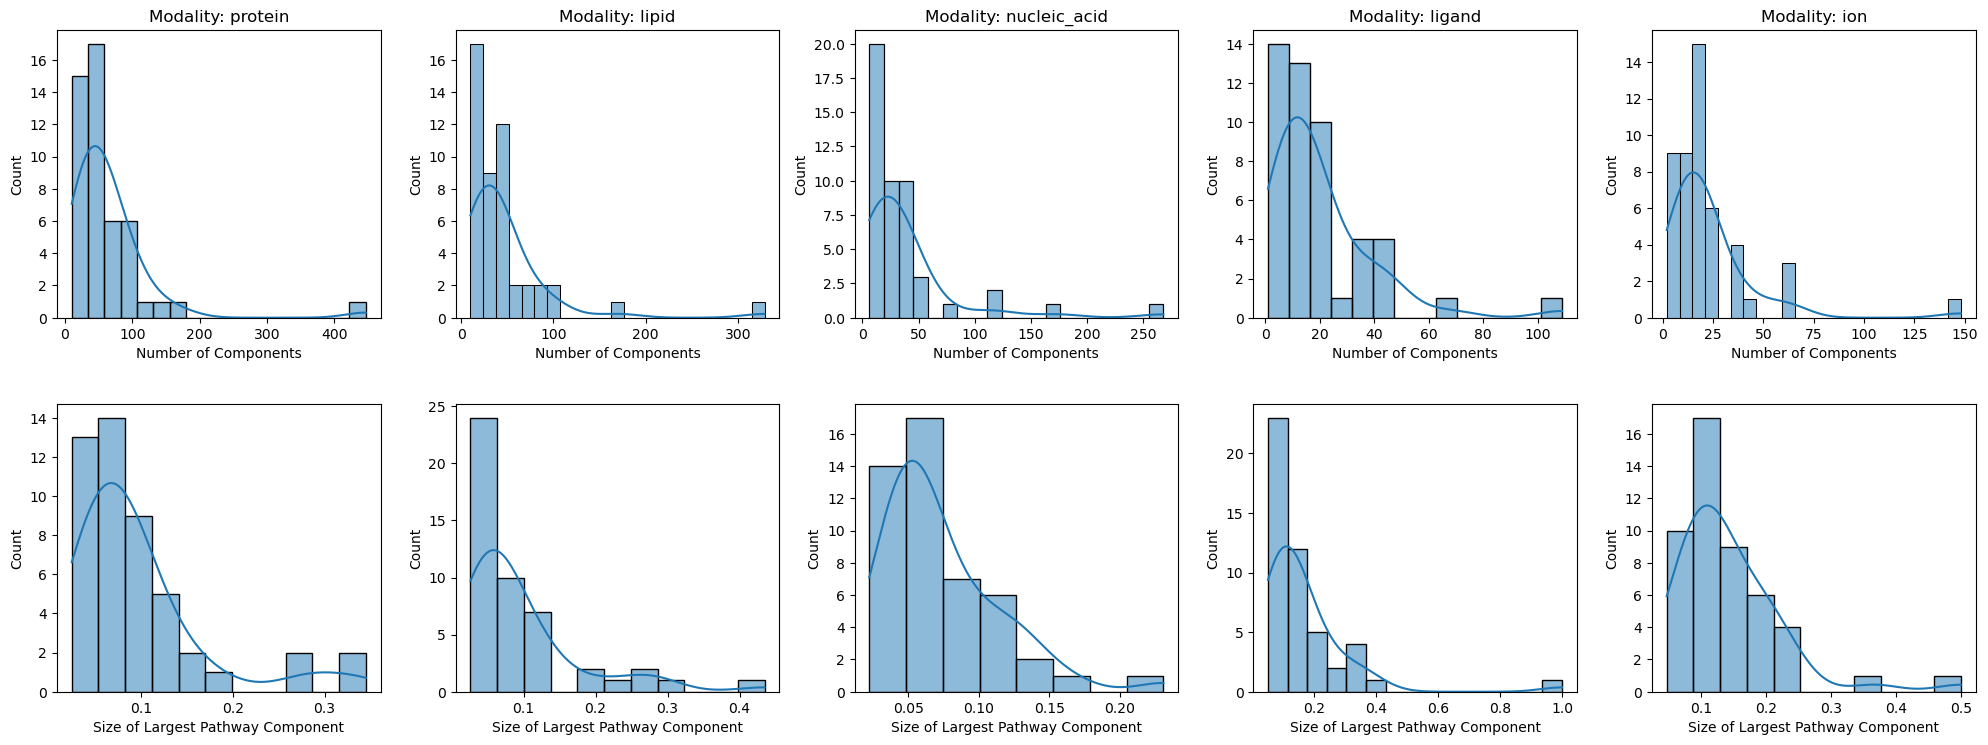

In [15]:
# Get unique modalities
modalities = disease_connectivity_df['modality'].unique()

# Create a figure with 5 columns and 2 rows
fig, axes = plt.subplots(2, 5, figsize=(20, 8))  # Adjust figsize as needed

# Create histograms for each modality
for i, modality in enumerate(modalities):
    if i < 5:  # Ensure we don't exceed the number of subplots
        # Filter data for the current modality
        data = disease_connectivity_df[disease_connectivity_df['modality'] == modality]
        
        # Create histogram for num_components
        sns.histplot(data=data, x='num_components', ax=axes[0, i], kde=True)
        axes[0, i].set_title(f'Modality: {modality}')
        axes[0, i].set_xlabel('Number of Components')
        axes[0, i].set_ylabel('Count')
        
        # Create histogram for size_of_largest_pathway_component
        sns.histplot(data=data, x='size_of_largest_pathway_component', ax=axes[1, i], kde=True)
        axes[1, i].set_xlabel('Size of Largest Pathway Component')
        axes[1, i].set_ylabel('Count')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.9, hspace=0.3)

# Show the plot
plt.show()

## Diamond algorithm

In [3]:
from glob import glob
num_completed = len(glob("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_*.pkl"))
num_completed

100

In [4]:
import pandas as pd
import pickle 
import os

results_df = pd.DataFrame()
for i in range(100):
    fname = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500_split_{i}.pkl"
    if not os.path.exists(fname):
        print(f"{i} does not exist")
        continue
    with open(fname, "rb") as f:
        results = pickle.load(f)
        results_df = pd.concat([results_df, results])

In [5]:
with open("/n/holylfs06/LABS/mzitnik_lab/Lab/afang/protein_universe/human_proteome/disease_network_analysis/results_at_pesto_70_plddt_70_max_500.pkl", "wb") as f:
    pickle.dump(results_df, f)

In [14]:
num_found_per_disease = []
for disease in tqdm(results_df['diseaseName'].unique(), total=len(results_df['diseaseName'].unique())):
    for modality in ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']:
        found_proteins = sum(results_df[(results_df['diseaseName'] == disease) & (results_df['modality'] == modality)]['found_rw'].dropna().values.tolist(), [])
        found_proteins = set(found_proteins)
        gt_proteins = disease_associations[disease_associations['diseaseName'] == disease]['uniprot_targetId'].unique()
        found_proteins = found_proteins.intersection(set(gt_proteins))
        num_found_per_disease.append((disease, modality, len(found_proteins), found_proteins))
num_found_per_disease_df = pd.DataFrame(num_found_per_disease, columns=['diseaseName', 'modality', 'num_found_proteins', 'found_proteins'])

  0%|          | 0/97 [00:00<?, ?it/s]

100%|██████████| 97/97 [01:03<00:00,  1.53it/s]


Some dieaseases worth further study based on proteins detected
- breast neoplasms
- colorectal neoplasms
- multiple sclerosis
- lymphoma

In [15]:
num_found_per_disease_per_modality_df = num_found_per_disease_df.pivot_table(index='diseaseName', columns='modality', values='num_found_proteins', fill_value=0).reset_index()
num_found_per_disease_per_modality_df.head(50)

modality,diseaseName,ion,ligand,lipid,nucleic_acid,protein
0,Alzheimer disease,0.0,0.0,4.0,0.0,4.0
1,CNS demyelinating autoimmune disease,25.0,4.0,36.0,5.0,19.0
2,Charcot-Marie-Tooth disease,2.0,0.0,0.0,3.0,4.0
3,Joubert syndrome,0.0,0.0,0.0,0.0,4.0
4,Leigh syndrome,0.0,0.0,0.0,0.0,2.0
5,Noonan syndrome,0.0,11.0,0.0,0.0,2.0
6,Parkinson disease,5.0,9.0,19.0,0.0,4.0
7,Spinocerebellar ataxia with oculomotor anomaly,0.0,0.0,0.0,0.0,1.0
8,T-cell and NK-cell neoplasm,0.0,0.0,0.0,0.0,0.0
9,adrenal gland disease,0.0,0.0,7.0,0.0,4.0


In [16]:
mean_results_df = results_df.groupby(['diseaseId', 'diseaseName', 'modality']).agg({
    # 'found_diamond': lambda x: sum(x, []),
    # 'found_rw': lambda x: sum(x, []),
    # 'found_neighborhood': lambda x: sum(x, []),
    'num_found_diamond': 'sum',
    'num_found_rw': 'sum',
    'num_found_neighborhood': 'sum',
    'recall_diamond': 'mean',
    'recall_rw': 'mean',
    'recall_neighborhood': 'mean',
    # 'gt_proteins': lambda x: sum(x, []),
}).reset_index()

In [17]:
mean_results_df.groupby(['diseaseId', 'diseaseName']).agg({'num_found_diamond':'sum'}).sort_values('num_found_diamond', ascending=False)

,,num_found_diamond
diseaseId,diseaseName,
OTAR_0000020,nutritional or metabolic disease,32142
EFO_0003869,breast neoplasm,7306
EFO_0000474,epilepsy,6467
MONDO_0004736,inborn disorder of amino acid metabolism,5200
EFO_1000870,CNS demyelinating autoimmune disease,5136
...,...,...
MONDO_0003689,familial hemolytic anemia,21
MONDO_0004139,normocytic anemia,13
EFO_0005540,bile duct carcinoma,8


In [18]:
print("Discovered by Diamond: ", mean_results_df['recall_diamond'].mean(), mean_results_df['recall_diamond'].std())
print("Discovered by Random Walk: ", mean_results_df['recall_rw'].mean(), mean_results_df['recall_rw'].std())
print("Discovered by Neighborhood: ", mean_results_df['recall_neighborhood'].mean(), mean_results_df['recall_neighborhood'].std())

Discovered by Diamond:  0.09009170700570168 0.06438658935536169
Discovered by Random Walk:  0.10014728858241376 0.0877759856502437
Discovered by Neighborhood:  0.09840378576126564 0.0877304791627646


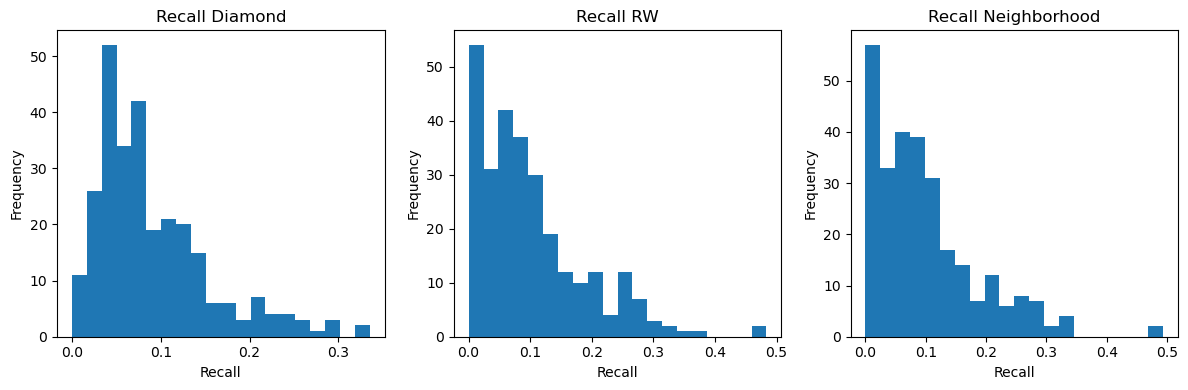

In [19]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
mean_results_df['recall_diamond'].hist(bins=20, ax=ax1)
mean_results_df['recall_rw'].hist(bins=20, ax=ax2)
mean_results_df['recall_neighborhood'].hist(bins=20, ax=ax3)
ax1.set_title('Recall Diamond')
ax2.set_title('Recall RW')
ax3.set_title('Recall Neighborhood')
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Recall')
    ax.set_ylabel('Frequency')
    ax.grid(False)
plt.tight_layout()
plt.show()

## Analyse a specific disease

In [209]:
chosen_disease_name = 'hypertrophic cardiomyopathy'
chosen_disease = disease_name_to_id[chosen_disease_name]
print("Chosen disease ID:", chosen_disease)
modality_disease_counts.loc[(chosen_disease, chosen_disease_name)]

Chosen disease ID: EFO_0000538


modality
ion             42.0
ligand          44.0
lipid           25.0
nucleic_acid    30.0
protein         80.0
is_valid        True
Name: (EFO_0000538, hypertrophic cardiomyopathy), dtype: object

Number of ground truth proteins:  105


  0%|          | 0/2500 [00:00<?, ?it/s]

100%|██████████| 2500/2500 [00:00<00:00, 8896.26it/s]
/tmp/ipykernel_952064/3979721867.py:33: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  found_matrix[i,j] = found['count']


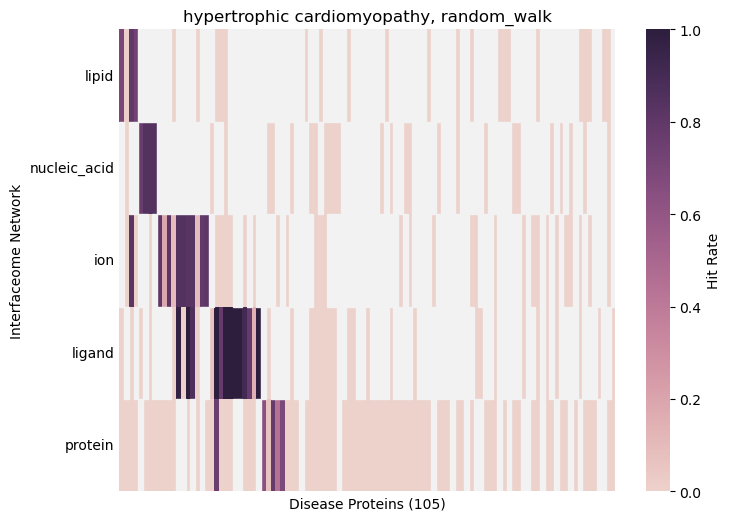

In [210]:
chosen_method = 'random_walk'
chosen_disease = disease_name_to_id[chosen_disease_name]

modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
gt_proteins = set(disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].to_list())
print("Number of ground truth proteins: ", len(gt_proteins))

found_list = []
for _, row in tqdm(results_df[results_df['diseaseId'] == chosen_disease].iterrows(), total=len(results_df[results_df['diseaseId'] == chosen_disease])):
    if row['found_diamond'] is pd.NA:
        row['found_diamond'] = []
    if row['found_rw'] is pd.NA:
        row['found_rw'] = []
    if row['found_neighborhood'] is pd.NA:
        row['found_neighborhood'] = []
    for found_prot in set(row['found_diamond']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "diamond"})
    for found_prot in set(row['found_rw']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "random_walk"})
    for found_prot in set(row['found_neighborhood']).intersection(gt_proteins):
        found_list.append({"modality": row['modality'], "found_prot": found_prot, "model": "neighborhood"})
found_df = pd.DataFrame(found_list)
found_df = found_df.groupby(['modality', 'model', 'found_prot']).size().reset_index(name='count')


found_matrix = np.zeros((len(modalities), len(gt_proteins)))

num_trials = results_df[results_df['diseaseId'] == chosen_disease][['modality', 'fold']].value_counts().mean()
for i, modality in enumerate(modalities):
    for j, protein in enumerate(gt_proteins):
        found = found_df[(found_df['modality'] == modality) & (found_df['model'] == chosen_method) & (found_df['found_prot'] == protein)]
        if len(found) > 0:
            found_matrix[i,j] = found['count']
        elif not protein in modality_graphs[modality]['uniprot_to_node_idx']:
            found_matrix[i,j] = -1
        else:
            protein_idx = modality_graphs[modality]['uniprot_to_node_idx'][protein]
            if protein_idx in modality_graphs[modality]['largest_component']:
                found_matrix[i,j] = 0
            else:
                found_matrix[i,j] = -1
found_matrix[found_matrix > 0] = found_matrix[found_matrix > 0] / num_trials
assert found_matrix.max() <= 1

protein_order = []
modality_order = (found_matrix >= 0).sum(axis=1).argsort()
for modality in modality_order: # order modalities by number of found proteins
    for prot in np.where(found_matrix[modality] > 0)[0]:
        if prot not in protein_order:
            protein_order.append(prot)
for i in range(found_matrix.shape[1]):
    if i not in protein_order:
        protein_order.append(i)
found_matrix = found_matrix[:,protein_order]
found_matrix = found_matrix[modality_order]

plt.figure(figsize=(8, 6))
mask = found_matrix==-1
ax = sns.heatmap(found_matrix, cmap=sns.cubehelix_palette(as_cmap=True), mask=mask, cbar_kws={"label": "Hit Rate"}, vmin=0, vmax=1)
for i, j in zip(*np.where(mask)):
    plt.gca().add_patch(plt.Rectangle((j, i), 1, 1, fc='#F2F2F2', ec='#F2F2F2'))

plt.yticks(np.arange(len(modalities))+0.5, np.array(modalities)[modality_order], rotation=0)
if len(gt_proteins) < 50:
    plt.xticks(np.arange(len(gt_proteins))+0.5, np.array(list(gt_proteins))[protein_order], rotation=90)
else:
    ax.set_xticklabels([])
    ax.set_xticks([])
ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)
plt.title(f"{disease_id_to_name[chosen_disease]}, {chosen_method}")
plt.ylabel("Interfaceome Network")
plt.xlabel(f"Disease Proteins ({len(gt_proteins)})")
plt.show()
        

In [220]:
modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
gt_proteins = set(disease_associations[disease_associations['diseaseId'] == chosen_disease]['uniprot_targetId'].to_list())

protein_ranks = {modality: defaultdict(list) for modality in modalities}
for _, row in results_df[results_df['diseaseId'] == chosen_disease].iterrows():
    if row['found_rw'] is pd.NA:
        continue
    for i, prot in enumerate(row['found_rw']):
        protein_ranks[row['modality']][prot].append(i)

mean_protein_rank = {modality: {prot: np.mean(ranks) for prot, ranks in protein_ranks[modality].items()} for modality in modalities}
median_protein_rank = {modality: {prot: np.median(ranks) for prot, ranks in protein_ranks[modality].items()} for modality in modalities}
std_protein_rank = {modality: {prot: np.std(ranks) for prot, ranks in protein_ranks[modality].items()} for modality in modalities}

for modality in modalities:
    mean_protein_rank_ = sorted(mean_protein_rank[modality].items(), key=lambda x: x[1])
    mean_protein_rank[modality] = {prot: rank for rank, (prot, mean_rank) in enumerate(mean_protein_rank_)}
    median_protein_rank_ = sorted(median_protein_rank[modality].items(), key=lambda x: x[1])
    median_protein_rank[modality] = {prot: rank for rank, (prot, median_rank) in enumerate(median_protein_rank_)}

max_rank = 500
mean_rank_top_proteins = {modality: [prot for prot, rank in mean_protein_rank[modality].items() if rank < max_rank] for modality in modalities}
median_rank_top_proteins = {modality: [prot for prot, rank in median_protein_rank[modality].items() if rank < max_rank] for modality in modalities}
uniprots_in_modality = {}
for modality in modalities:
    node_idx_to_uniprot = {v: k for k, v in modality_graphs[modality]['uniprot_to_node_idx'].items()}
    uniprots_in_modality[modality] = [node_idx_to_uniprot[x] for x in modality_graphs[modality]['largest_component']]
    print(modality, f"num found in mean rank top {max_rank}: {len(set(mean_rank_top_proteins[modality]).intersection(gt_proteins))}, \
          num found in median rank top {max_rank}: {len(set(median_rank_top_proteins[modality]).intersection(gt_proteins))}, \
          total in modality graph: {len(gt_proteins.intersection(uniprots_in_modality[modality]))}")

protein num found in mean rank top 500: 4,           num found in median rank top 500: 4,           total in modality graph: 80
lipid num found in mean rank top 500: 3,           num found in median rank top 500: 3,           total in modality graph: 25
nucleic_acid num found in mean rank top 500: 3,           num found in median rank top 500: 3,           total in modality graph: 30
ligand num found in mean rank top 500: 12,           num found in median rank top 500: 12,           total in modality graph: 44
ion num found in mean rank top 500: 9,           num found in median rank top 500: 9,           total in modality graph: 42


In [221]:
for prot in gt_proteins.intersection(uniprots_in_modality['nucleic_acid']):
    print(prot, "|", uniprot_to_gene.get(prot, prot), "|", uniprot_to_protein_name.get(prot, prot))

Q13233 | MAP3K1 MAPKKK1 MEKK MEKK1 | Mitogen-activated protein kinase kinase kinase 1 (EC 2.7.11.25) (MAPK/ERK kinase kinase 1) (MEK kinase 1) (MEKK 1) (EC 2.3.2.27)
P19429 | TNNI3 TNNC1 | Troponin I, cardiac muscle (Cardiac troponin I)
P18206 | VCL | Vinculin (Metavinculin) (MV)
P35609 | ACTN2 | Alpha-actinin-2 (Alpha-actinin skeletal muscle isoform 2) (F-actin cross-linking protein)
Q9Y490 | TLN1 KIAA1027 TLN | Talin-1
P41240 | CSK | Tyrosine-protein kinase CSK (EC 2.7.10.2) (C-Src kinase) (Protein-tyrosine kinase CYL)
Q96L73 | NSD1 ARA267 KMT3B | Histone-lysine N-methyltransferase, H3 lysine-36 specific (EC 2.1.1.357) (Androgen receptor coactivator 267 kDa protein) (Androgen receptor-associated protein of 267 kDa) (H3-K36-HMTase) (Lysine N-methyltransferase 3B) (Nuclear receptor-binding SET domain-containing protein 1) (NR-binding SET domain-containing protein)
Q0ZGT2 | NEXN | Nexilin (F-actin-binding protein) (Nelin)
Q8WXI2 | CNKSR2 CNK2 KIAA0902 KSR2 | Connector enhancer of kinase

### Does evidence count or score vary by rank

In [212]:
all_evidence_scores_df = pd.read_csv('/n/holylfs06/LABS/mzitnik_lab/Lab/afang/disease_network/open_target_2024_09/associationByOverallIndirect_uniprot.csv')

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beh

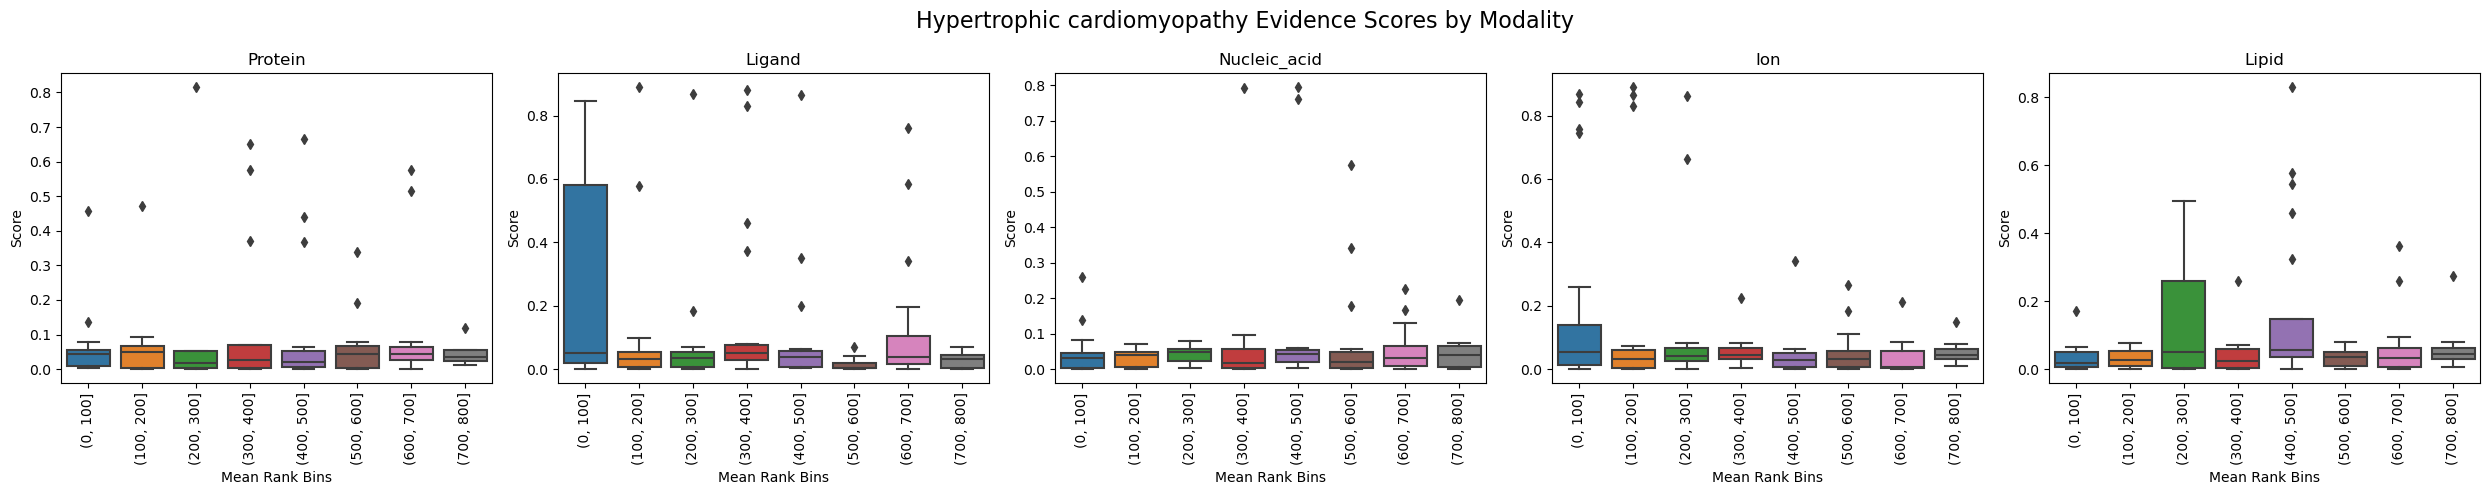

In [213]:
disease_evidence_scores = all_evidence_scores_df[all_evidence_scores_df['diseaseId'] == chosen_disease].copy()
modalities = ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']
for modality in modalities:
    disease_evidence_scores[f'{modality}_mean_rank'] = disease_evidence_scores['uniprot_targetId'].map(mean_protein_rank[modality])

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(f'{chosen_disease_name.capitalize()} Evidence Scores by Modality', fontsize=16)
bins = np.arange(0, 801, 100)
for i, modality in enumerate(modalities):
    disease_evidence_scores_modality = disease_evidence_scores.dropna(subset=[f'{modality}_mean_rank']).copy()
    disease_evidence_scores_modality['rank_bin'] = pd.cut(disease_evidence_scores_modality[f'{modality}_mean_rank'], bins=bins)
    sns.boxplot(
        data=disease_evidence_scores_modality,
        x='rank_bin',
        y='score',
        ax=axes[i]
    )
    axes[i].set_title(modality.capitalize())
    axes[i].set_xlabel('Mean Rank Bins')
    axes[i].set_ylabel('Score')
    
    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

/tmp/ipykernel_952064/869966329.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = disease_evidence_scores_modality[disease_evidence_scores_modality['score'] > score_cutoff].groupby('rank_bin').size()
/tmp/ipykernel_952064/869966329.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = disease_evidence_scores_modality[disease_evidence_scores_modality['score'] > score_cutoff].groupby('rank_bin').size()
/tmp/ipykernel_952064/869966329.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curre

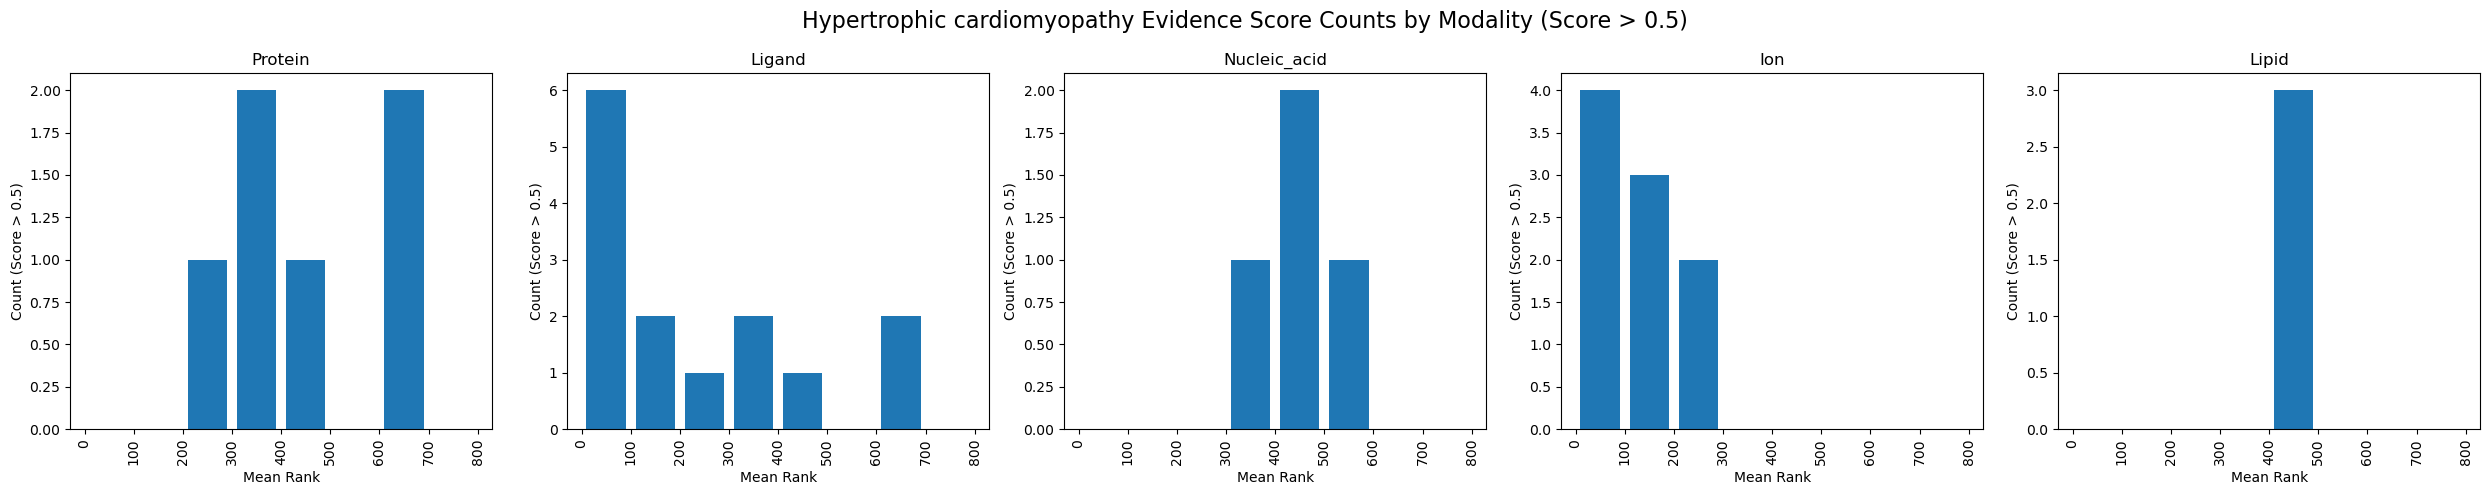

In [214]:
score_cutoff = 0.5
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle(f'{chosen_disease_name.capitalize()} Evidence Score Counts by Modality (Score > {score_cutoff})', fontsize=16)

modalities = ['protein', 'ligand', 'nucleic_acid', 'ion', 'lipid']
bins = np.arange(0, 801, 100)
bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for x-axis

for i, modality in enumerate(modalities):
    disease_evidence_scores_modality = disease_evidence_scores.dropna(subset=[f'{modality}_mean_rank']).copy()
    disease_evidence_scores_modality['rank_bin'] = pd.cut(disease_evidence_scores_modality[f'{modality}_mean_rank'], bins=bins)
    
    # Count items in each bin where score > 0.5
    counts = disease_evidence_scores_modality[disease_evidence_scores_modality['score'] > score_cutoff].groupby('rank_bin').size()
    
    # Plot the counts
    axes[i].bar(bin_centers, counts.values, width=80)
    
    axes[i].set_title(modality.capitalize())
    axes[i].set_xlabel('Mean Rank')
    axes[i].set_ylabel(f'Count (Score > {score_cutoff})')
    
    # Set x-axis ticks to bin edges
    axes[i].set_xticks(bins)
    axes[i].set_xticklabels(bins, rotation=90)

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [215]:
for modality in modalities:
    disease_evidence_scores_modality = disease_evidence_scores.dropna(subset=f'{modality}_mean_rank').copy()
    disease_evidence_scores_modality.sort_values(f'{modality}_mean_rank', inplace=True)
    print(modality, "\n", disease_evidence_scores_modality[[f'{modality}_mean_rank', 'score', 'evidenceCount']].head(10), disease_evidence_scores_modality[[f'{modality}_mean_rank', 'score', 'evidenceCount']].tail(10))

protein 
         protein_mean_rank     score  evidenceCount
981875                2.0  0.014846             10
983195                5.0  0.054355              3
983633                7.0  0.030476              1
984605               11.0  0.038372              2
984314               12.0  0.025231              7
981766               18.0  0.007392              1
983217               21.0  0.049285              3
984795               23.0  0.046347              4
982913               35.0  0.054352              2
982352               39.0  0.049165              2         protein_mean_rank     score  evidenceCount
981778              677.0  0.575817             11
982180              679.0  0.040802              2
984665              693.0  0.042598              2
982021              694.0  0.011087              1
983654              700.0  0.002217              1
983932              707.0  0.118266              1
984188              708.0  0.023136              1
982992              7

### Which proteins were nominated

In [ ]:
modalities = ['protein', 'lipid', 'nucleic_acid', 'ligand', 'ion']
uniprots_in_modality = {}
for modality in modalities:
    node_idx_to_uniprot = {v: k for k, v in modality_graphs[modality]['uniprot_to_node_idx'].items()}
    uniprots_in_modality[modality] = [node_idx_to_uniprot[x] for x in modality_graphs[modality]['largest_component']]

found_proteins = found_df[found_df.model == chosen_method].pivot_table(index='found_prot', columns='modality', values='count').fillna(0)
for modality in modalities:
    if not modality in found_proteins.columns:
        print(f"Ignoring modality = {modality} due to insufficient data")
    else:
        found_proteins.loc[~found_proteins.index.isin(uniprots_in_modality[modality]), modality] = pd.NA

found_proteins['gene'] = found_proteins.index.map(uniprot_to_gene)
found_proteins['protein_name'] = found_proteins.index.map(uniprot_to_protein_name)
print("Number of found proteins: ", len(found_proteins))
found_proteins.sort_values(by='nucleic_acid', ascending=False).head(50)

Number of found proteins:  35


modality,ion,ligand,lipid,nucleic_acid,protein,gene,protein_name
found_prot,,,,,,,
P18206,NaN,NaN,NaN,85.0,0.0,VCL,Vinculin (Metavinculin) (MV)
Q86TC9,NaN,NaN,NaN,85.0,0.0,MYPN MYOP,Myopalladin (145 kDa sarcomeric protein)
Q13233,0.0,0.0,NaN,85.0,0.0,MAP3K1 MAPKKK1 MEKK MEKK1,Mitogen-activated protein kinase kinase kinase...
P41240,NaN,0.0,NaN,77.0,NaN,CSK,Tyrosine-protein kinase CSK (EC 2.7.10.2) (C-S...
P13533,0.0,100.0,0.0,0.0,0.0,MYH6 MYHCA,Myosin-6 (Myosin heavy chain 6) (Myosin heavy ...
Q07889,NaN,NaN,NaN,0.0,78.0,SOS1,Son of sevenless homolog 1 (SOS-1)
P27448,NaN,0.0,NaN,0.0,7.0,MARK3 CTAK1 EMK2,MAP/microtubule affinity-regulating kinase 3 (...
Q13285,0.0,NaN,1.0,0.0,0.0,NR5A1 AD4BP FTZF1 SF1,Steroidogenic factor 1 (SF-1) (STF-1) (hSF-1) ...
Q9UQ13,NaN,7.0,NaN,0.0,0.0,SHOC2 KIAA0862,Leucine-rich repeat protein SHOC-2 (Protein so...


In [219]:
sum(found_proteins['nucleic_acid'].notna())

9

In [217]:
K_channel_proteins = [
"P51787", "Q9UK17", "Q12809", "P16389", "Q09470", "O43526", "O43525", "Q96RP8", "Q9NR82", "P56696", "O95259", "P22459", "P22460", "P22001", "P17658", "P48547", "Q9NZV8", "Q92953", "Q03721", "Q14003", "Q14721", "Q16322", "Q6PIU1", "Q8NCM2", "Q8TAE7", "Q8TDN1", "Q8TDN2", "Q96KK3", "Q96L42", "Q96PR1", "Q9BQ31", "Q9H252", "Q9H3M0", "Q9NS40", "Q9NSA2", "Q9UIX4", "Q9UJ96", "Q9ULD8", "Q9ULS6", "Q9UQ05",
] # Voltage-gated potassium channel", "https://www.ebi.ac.uk/chembl/explore/target/CHEMBL2362996

NA_channel_proteins = [
    "P35498", "Q14524", "P35499", "Q01118", "Q99250", "Q15858", "Q9NY46", "Q9UI33", "Q9UQD0", "Q9Y5Y9",
] # Sodium channel alpha subunit, https://www.ebi.ac.uk/chembl/explore/target/CHEMBL2331043

chosen_modality = 'nucleic_acid'
found_proteins_modality = found_proteins[['gene','protein_name', chosen_modality]].copy()
found_proteins_modality['mean_rank'] = found_proteins_modality.index.map(mean_protein_rank[chosen_modality])
found_proteins_modality['median_rank'] = found_proteins_modality.index.map(median_protein_rank[chosen_modality])
found_proteins_modality['std_rank'] = found_proteins_modality.index.map(std_protein_rank[chosen_modality])
found_proteins_modality['in_K_channel'] = found_proteins_modality.index.isin(K_channel_proteins)
found_proteins_modality['in_Na_channel'] = found_proteins_modality.index.isin(NA_channel_proteins)
found_proteins_modality.sort_values('mean_rank').head(50)

modality,gene,protein_name,nucleic_acid,mean_rank,median_rank,std_rank,in_K_channel,in_Na_channel
found_prot,,,,,,,,
Q86TC9,MYPN MYOP,Myopalladin (145 kDa sarcomeric protein),85.0,372.0,387.0,31.605799,False,False
Q13233,MAP3K1 MAPKKK1 MEKK MEKK1,Mitogen-activated protein kinase kinase kinase...,85.0,441.0,440.0,29.824734,False,False
P18206,VCL,Vinculin (Metavinculin) (MV),85.0,460.0,460.0,32.142029,False,False
P41240,CSK,Tyrosine-protein kinase CSK (EC 2.7.10.2) (C-S...,77.0,560.0,571.0,34.446259,False,False
A7E2Y1,MYH7B KIAA1512,Myosin-7B (Antigen MLAA-21) (Myosin cardiac mu...,NaN,NaN,NaN,NaN,False,False
O14807,MRAS RRAS3,Ras-related protein M-Ras (EC 3.6.5.2) (Ras-re...,NaN,NaN,NaN,NaN,False,False
P01111,NRAS HRAS1,GTPase NRas (EC 3.6.5.2) (Transforming protein...,NaN,NaN,NaN,NaN,False,False
P01112,HRAS HRAS1,GTPase HRas (EC 3.6.5.2) (H-Ras-1) (Ha-Ras) (T...,NaN,NaN,NaN,NaN,False,False
P01116,KRAS KRAS2 RASK2,GTPase KRas (EC 3.6.5.2) (K-Ras 2) (Ki-Ras) (c...,NaN,NaN,NaN,NaN,False,False


In [206]:
found_proteins_modality['in_K_channel'][found_proteins_modality[chosen_modality].notna() & found_proteins_modality[chosen_modality]!=0].sum()

25

In [207]:
found_proteins_modality['in_Na_channel'][found_proteins_modality[chosen_modality].notna() & found_proteins_modality[chosen_modality]!=0].sum()

0

In [208]:
found_proteins_modality.reset_index().to_csv(f'results/{chosen_disease_name.replace(" ", "_")}_random_walk_found_proteins_{chosen_modality}.csv', index=False)

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

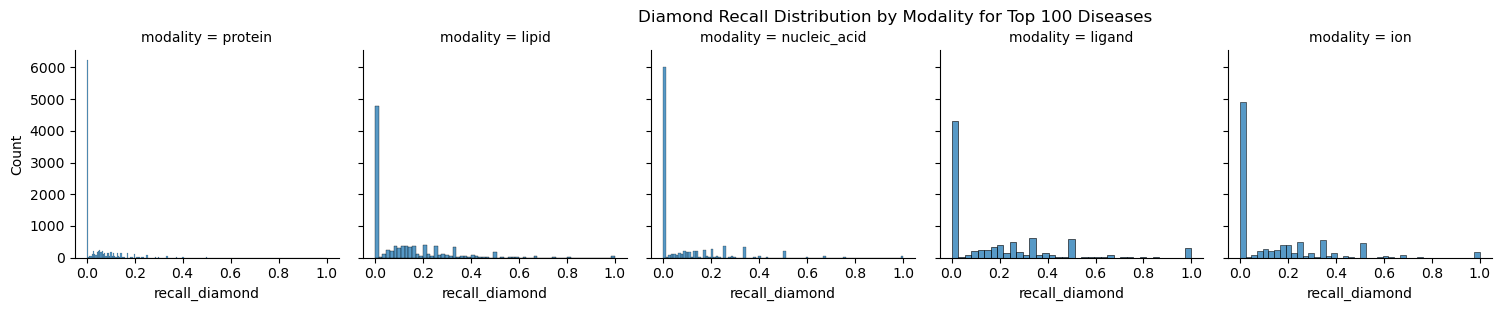

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

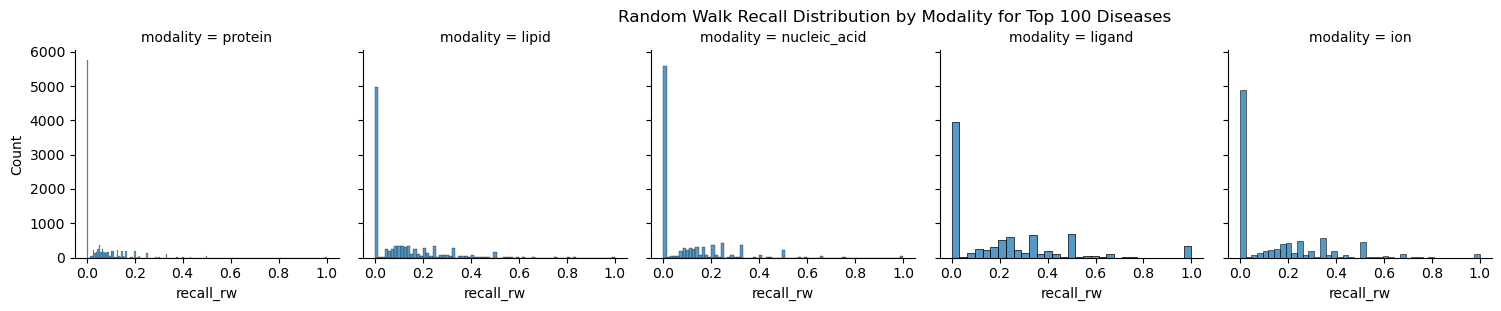

/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/n/home13/afang/.conda/envs/interactenv1/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na 

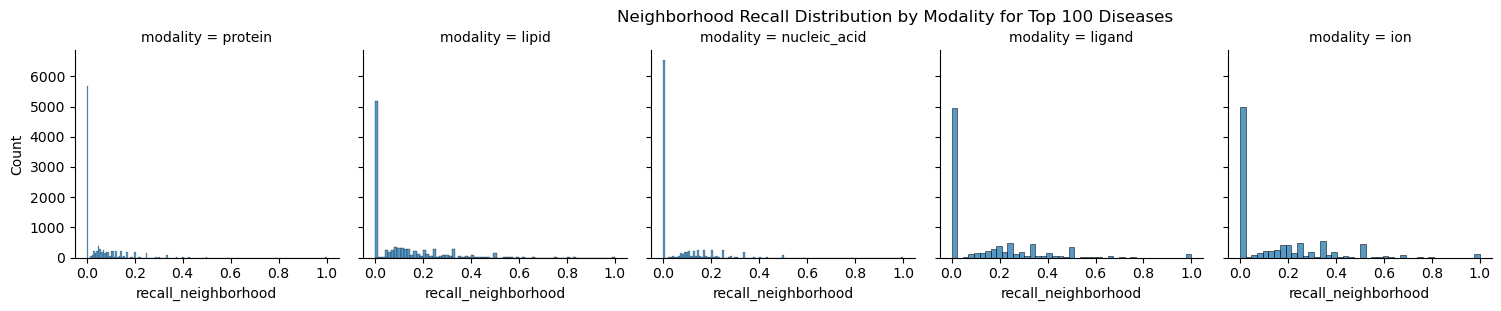

In [108]:
results_df_diamond = results_df.dropna(subset=["recall_diamond"])
results_df_rw = results_df.dropna(subset=["recall_rw"])
results_df_neighborhood = results_df.dropna(subset=["recall_neighborhood"])

# Plot for 'recall_diamond'
g = sns.FacetGrid(results_df_diamond, col="modality", col_wrap=6, sharex=True, sharey=True)
g.map(sns.histplot, "recall_diamond", kde=False)

# Add a title for the entire plot grid
g.fig.suptitle("Diamond Recall Distribution by Modality for Top 100 Diseases", y=1.02)

plt.show()

# Plot for 'recall_rw'
g = sns.FacetGrid(results_df_rw, col="modality", col_wrap=6, sharex=True, sharey=True)
g.map(sns.histplot, "recall_rw", kde=False)

# Add a title for the entire plot grid
g.fig.suptitle("Random Walk Recall Distribution by Modality for Top 100 Diseases", y=1.02)

plt.show()

# Plot for 'recall_neighborhood'
g = sns.FacetGrid(results_df_neighborhood, col="modality", col_wrap=6, sharex=True, sharey=True)
g.map(sns.histplot, "recall_neighborhood", kde=False)

# Add a title for the entire plot grid
g.fig.suptitle("Neighborhood Recall Distribution by Modality for Top 100 Diseases", y=1.02)

plt.show()

Modality:  ion
Correlation between size of largest pathway component and recall:  0.5208397390293459


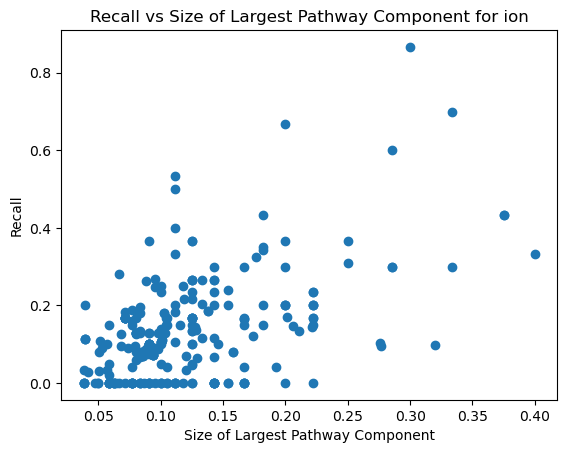

Modality:  ligand
Correlation between size of largest pathway component and recall:  0.40064699163275447


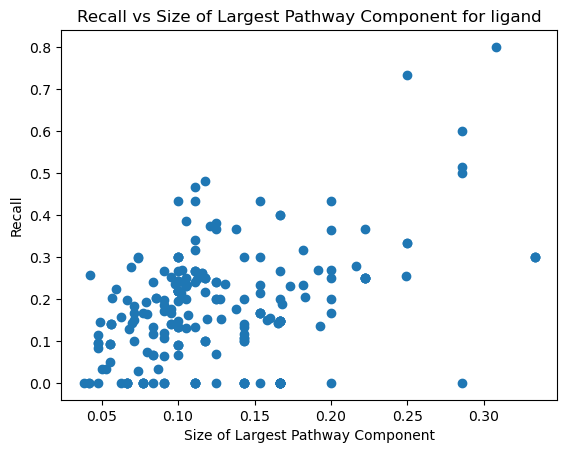

Modality:  lipid
Correlation between size of largest pathway component and recall:  0.40800261231543905


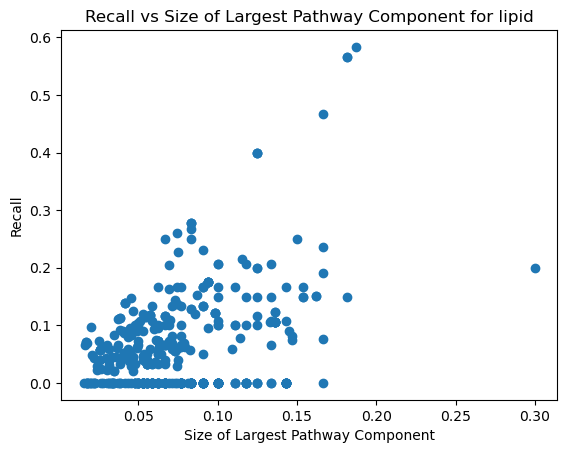

Modality:  nucleic_acid
Correlation between size of largest pathway component and recall:  0.3110333114425492


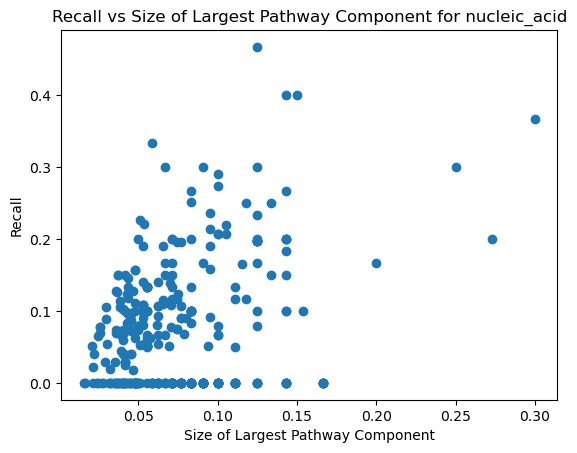

Modality:  protein
Correlation between size of largest pathway component and recall:  0.23484344897398568


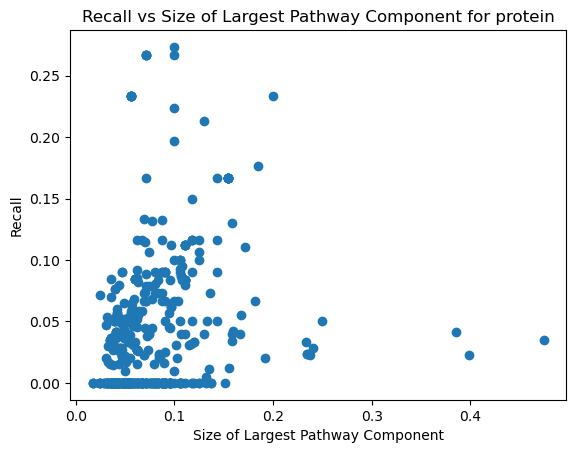

In [78]:
plot_df = mean_results_df.merge(disease_connectivity_df[['modality', 'text_id', 'size_of_largest_pathway_component', 'density', 'num_components']], left_on=['modality', 'disgenet_id'], right_on=['modality', 'text_id'])

for modality in plot_df['modality'].unique():
    modality_plot_df = plot_df[plot_df['modality'] == modality]
    print("Modality: ", modality)
    print("Correlation between size of largest pathway component and recall: ", modality_plot_df['size_of_largest_pathway_component'].corr(modality_plot_df['recall_rw']))
    plt.scatter(modality_plot_df['size_of_largest_pathway_component'], modality_plot_df['recall_rw'])
    plt.xlabel("Size of Largest Pathway Component")
    plt.ylabel("Recall")
    plt.title(f"Recall vs Size of Largest Pathway Component for {modality}")
    plt.show()

Modality:  protein
Correlation between num component and recall:  0.04423968759163139


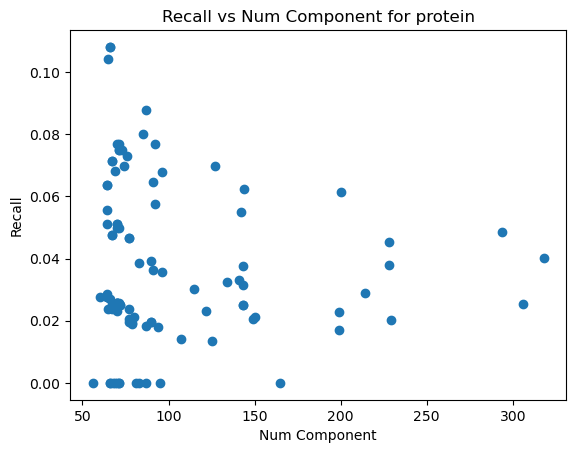

Modality:  lipid
Correlation between num component and recall:  0.517085347411038


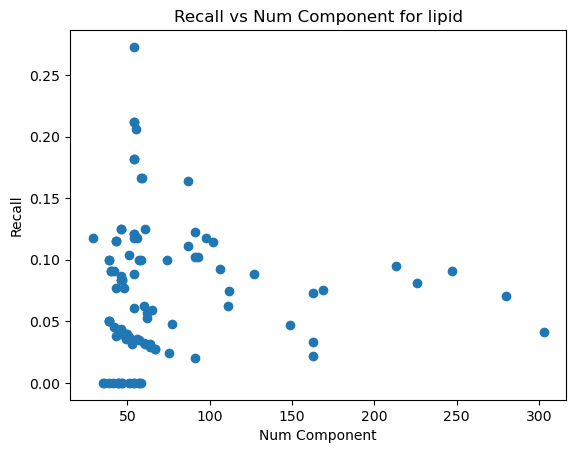

Modality:  nucleic_acid
Correlation between num component and recall:  0.04042377264059106


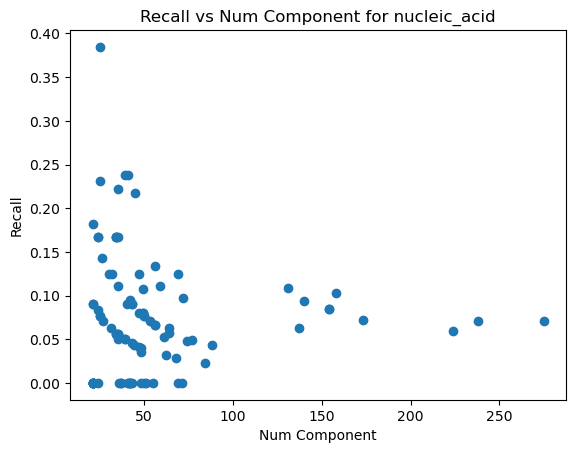

Modality:  ligand
Correlation between num component and recall:  0.22732488239006896


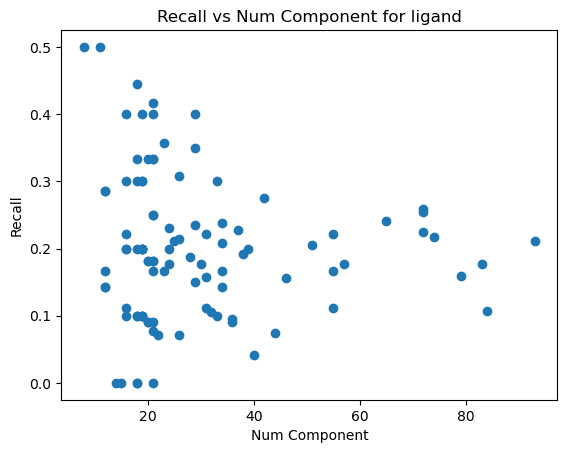

Modality:  ion
Correlation between num component and recall:  0.259175007918896


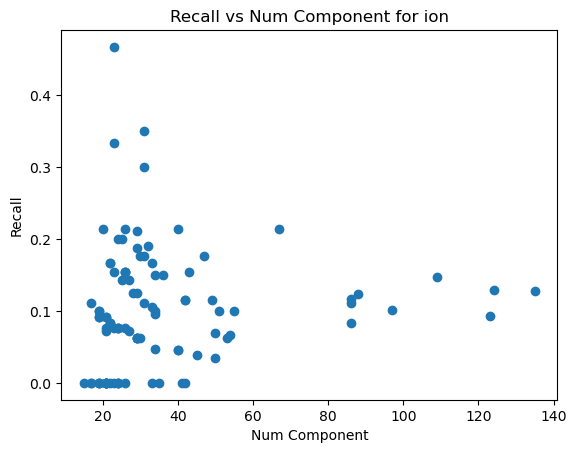

In [ ]:
for modality in plot_df['modality'].unique():
    modality_plot_df = plot_df[plot_df['modality'] == modality]
    print("Modality: ", modality)
    print("Correlation between num component and recall: ", modality_plot_df['size_of_largest_pathway_component'].corr(modality_plot_df['recall']))
    plt.scatter(modality_plot_df['num_components'], modality_plot_df['recall'])
    plt.xlabel("Num Component")
    plt.ylabel("Recall")
    plt.title(f"Recall vs Num Component for {modality}")
    plt.show()